In [2]:
%autoreload 2

In [1]:
%reload_ext autoreload

import numpy as np
import pandas as pd
import seaborn as sns
import sys, os, shutil
sys.path.append(r'C://Users//Zichen//anaconda3//envs//2ptank//Lib//site-packages//')
from fish import Gafftopsail, Coelacanth
import behavior_finder as bhfd
import utils
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from matplotlib.colors import LinearSegmentedColormap

pink = "#FB008C"
green = "#72D100"
cmap_conv = LinearSegmentedColormap.from_list("conv",[green, (1, 1, 1), pink])
cmap_conj = cm.get_cmap('coolwarm_r')

plt.rcParams.update({'font.size': 13})

C:\Users\Zichen\AppData\Local\Temp\ipykernel_27136\3211416424.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_conj = cm.get_cmap('coolwarm_r')


__BOUT FINDER__

In [4]:
path = "C://Data//Imaging//250912_overlap//fish"
all_df = []
fishlist = [
r"C:\Data\Imaging\250912_overlap\fish8",
r"C:\Data\Imaging\250912_overlap\fish9",
r"C:\Data\Imaging\250912_overlap\fish10",
r"C:\Data\Imaging\250912_overlap\fish13",
r"C:\Data\Imaging\250912_overlap\fish14",
r"C:\Data\Imaging\250912_overlap\fish15",
r"C:\Data\Imaging\250912_overlap\fish1",
r"C:\Data\Imaging\250912_overlap\fish2_2",
r"C:\Data\Imaging\250912_overlap\fish3",
r"C:\Data\Imaging\250912_overlap\fish4",
r"C:\Data\Imaging\250912_overlap\fish5_2",
r"C:\Data\Imaging\250912_overlap\fish7",
r"C:\Data\Imaging\251021_dotsweep\fish3_overlap",
r"C:\Data\Imaging\251021_dotsweep\fish5_overlap",
r"C:\Data\Imaging\251021_dotsweep\fish4_overlap"]
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df.csv', index_col=0)
    bout_df.loc[:, "fish_id"] = f
    all_df.append(bout_df)
    

all_df = pd.concat(all_df).reset_index(drop = True)

stimulus_df = Gafftopsail(f + '//', filelist = ['stimulus']).stimulus_df
#stimulus_df =Coelacanth(f + '//', filelist = ['stimulus']).stimulus_df
stimulus_df.loc[:, "stim_name"] = [str(s) for s in stimulus_df.stim_name]

#for overlap fishes
omr_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' not in i) and ('pause' not in i)]
dot_stim = [i for i in stimulus_df.stim_name.unique() if ('[' not in i) and ('dot' in i) and ('pause' not in i)]
overlap_stim = [i for i in stimulus_df.stim_name.unique() if ('dot' in i) & ('[' in i)]
stimlists = [omr_stim, dot_stim, overlap_stim]
#for dot fish
# stimlists = [['dot_l_3', 'dot_r_3'],['dot_l_5', 'dot_r_5'],['dot_l_10', 'dot_r_10'], ['dot_l_20', 'dot_r_20'],['dot_l_40', 'dot_r_40']]

In [109]:
#try to get the tail traces for all the fish
tail_collection = []
interesting_cols = [f"theta_{tail_seg}" if tail_seg >= 10 else f"theta_0{tail_seg}" for tail_seg in range(0, 13)]
frames = 50
for f in fishlist:
    bout_df = pd.read_csv(f + '//Tail//tail_bout_df.csv', index_col=0)
    bout_df.loc[:, "fish_id"] = f
    tail_df = pd.read_hdf(f + '//Tail//tail_df.hdf', index_col=0)
    for _, bout_row in bout_df.iterrows():
        cont_tuples = eval(bout_row.cont_tuples_tailindex)
        cont_tuples = (cont_tuples[0], cont_tuples[0] + frames)
        tail_trace = tail_df.loc[cont_tuples[0]:cont_tuples[1], interesting_cols].reset_index(drop = True)
        if len(tail_trace) < frames:
            tail_trace = tail_trace.reindex(range(frames + 1))
        tail_collection.append(tail_trace)

In [56]:
tail_collection[0].shape

(101, 13)

In [111]:
bout_collection =  np.stack(
    [df.to_numpy().ravel() for df in tail_collection],
    axis=0)
bout_collection = np.nan_to_num(bout_collection)

In [63]:
bout_collection.shape

(3183, 1313)

In [120]:
from openTSNE import TSNE as TSNE_fast
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


def bout_tsne_fast(bout_collection, kws = {'perplexity':500}):
    """
    Perform tsne on all the bouts
    """
    tsne = TSNE_fast(random_state=42, perplexity = kws['perplexity'], n_jobs=8)
    X_embedded = tsne.fit(bout_collection)
    return X_embedded

def bout_pca(bout_collection):
    """
    Perform tsne on all the bouts
    """
    x = StandardScaler().fit_transform(bout_collection)
    pca = PCA(n_components=3)
    X_embedded = pca.fit_transform(x)
    return X_embedded

In [121]:
#X_embedded = bout_tsne_fast(bout_collection, kws = {'perplexity':10})
X_embedded = bout_pca(bout_collection)


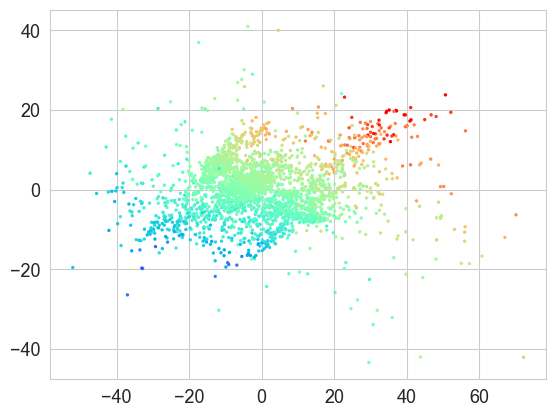

In [151]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s = 2, cmap = 'rainbow', c = all_df.tail_angle, vmin = -2, vmax = 2)

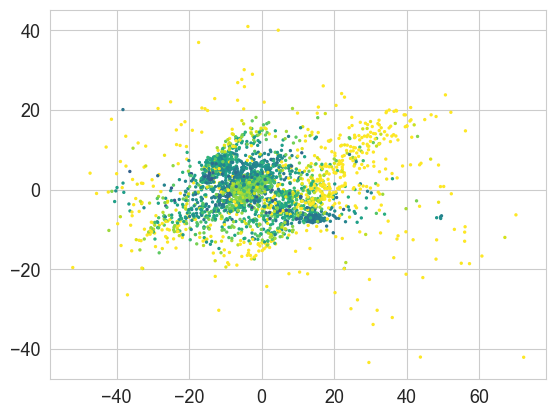

In [160]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s = 2, cmap = 'viridis', c = all_df.tail_strength, vmin = 0, vmax = .6)

In [148]:
dot_index = all_df[all_df.tail_realstimuli.isin(['dot_l', 'dot_r'])].index
dot_index



Index([   5,   26,   85,  339,  343,  473,  505,  529,  609,  610,  623,  624,
        625,  626,  627,  628,  630,  631,  632,  633,  662,  684,  705,  734,
        746,  747,  758,  759,  760,  788,  799,  800,  854,  912,  930,  941,
       1003, 1005, 1089, 1111, 1127, 1128, 1188, 1189, 1205, 1232, 1233, 1292,
       1301, 1334, 1335, 1336, 1337, 1360, 1361, 1495, 1541, 1581, 1656, 1770,
       1810, 1813, 1955, 1956, 1983, 2002, 2003, 2004, 2005, 2006, 2007, 2010,
       2011, 2140, 2800, 2808, 2815, 2836, 2887, 2911, 2913, 2985, 2986, 2987,
       2988, 3009, 3016, 3017, 3085, 3094, 3105, 3106, 3126, 3141, 3174, 3175,
       3176, 3182],
      dtype='int64')

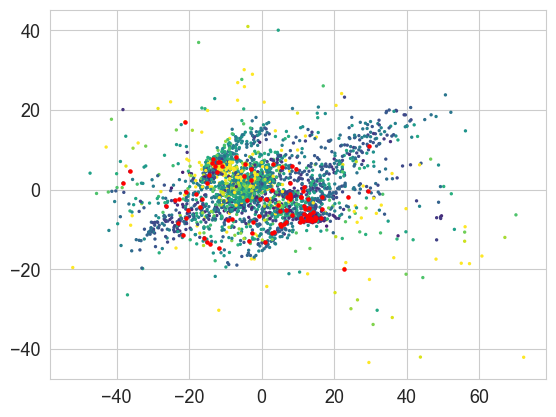

In [155]:
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], s = 2, cmap = 'viridis', c = all_df.tail_duration_s, vmin = 0, vmax = .6)
plt.scatter(X_embedded[dot_index, 0], X_embedded[dot_index, 1], s = 5, color = 'red')

In [156]:
all_df.columns

Index(['cont_tuples_tailindex', 'cont_tuples_realtime_s', 'tail_strength',
       'tail_angle', 'eye_vergence', 'tail_duration_s', 'tail_stimuli',
       'tail_realstimuli', 'tail_fromstart_s', 'fish_id'],
      dtype='object')